## Transcriptomic axes of the human hippocampus

**Overview**

In this tutorial, we will assess how gene expression is organized in the hippocampus using dimensionality reduction, namely diffusion map embedding.

**0 - Import libraries**

In [ ]:
import os
import sys

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

from brainspace.gradient import GradientMaps
from brainspace.mesh.mesh_io import read_surface

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

**1 - Load gene expression data**

In [ ]:
expression = hg.load_expression(data_dir=".")

/Users/alexngo/Repositories/toolboxes/hippogenes/.conda/lib/python3.9/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(


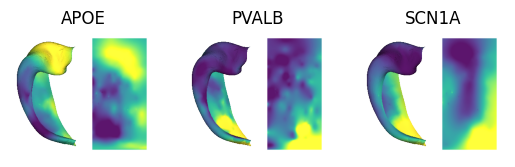

In [3]:
# Example genes:
genes = ["APOE", "PVALB", "SCN1A"]

fig, ax = plt.subplots(1,3)
for  i, g in enumerate(genes):
    cdata = expression[g].values
    hm.plotting.surfplot_canonical_foldunfold(cdata, cmap="viridis", hemis=['L'], labels=['hipp'],
                                              unfoldAPrescale=True, share='row', tighten_cwindow=True, 
                                              screenshot=True, filename=f'tmp_{g}.png')
    f = plt.imread(f'tmp_{g}.png')
    ax[i].imshow(f)
    ax[i].set_axis_off()
    ax[i].set_anchor("NW")
    ax[i].set_title(g)
    
!rm tmp*.png

**2 - Compute gradients**

In [4]:
# Diffusion map embedding (default parameters):
gm = GradientMaps(n_components=10, kernel="normalized_angle", approach="dm")
gm = gm.fit(expression.values, sparsity=0.9)

<BarContainer object of 10 artists>

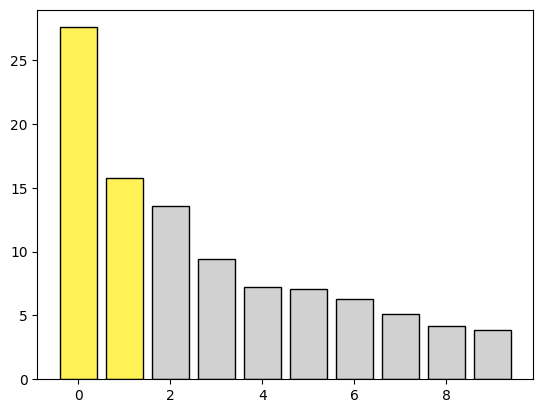

In [5]:
# Scaled eigenvalues:
total_lambda = np.sum(gm.lambdas_)
lambda_ratios = gm.lambdas_ / total_lambda * 100

color = ["#FFF156"] * 2 + ["#D1D1D1"] * 8 # Highlight the first two gradients, which explain the most variance in the data
plt.bar(range(10), lambda_ratios, color=color, edgecolor="k")

/Users/alexngo/Repositories/toolboxes/hippogenes/.conda/lib/python3.9/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(


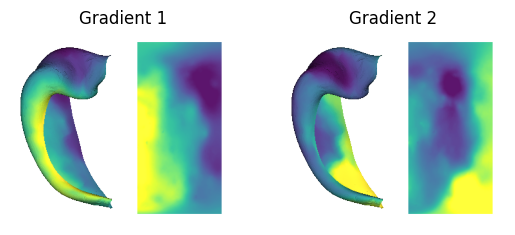

In [6]:
# First two eigenvectors:
fig, ax = plt.subplots(1, 2)
for  i in range(2):
    cdata = gm.gradients_[:, i]
    clim = (np.percentile(cdata, 5), np.percentile(cdata, 95))
    hm.plotting.surfplot_canonical_foldunfold(cdata, cmap="viridis", color_range=clim, hemis=['L'], 
                                              labels=['hipp'], unfoldAPrescale=True, share='row', 
                                              tighten_cwindow=True, screenshot=True, filename=f'tmp_{i}.png')
    f = plt.imread(f'tmp_{i}.png')
    ax[i].imshow(f)
    ax[i].set_axis_off()
    ax[i].set_anchor("NW")
    ax[i].set_title(f"Gradient {i+1}")
    
!rm tmp*.png